# Gaia recheck + sigma calibration for the adopted anchored head

Two pre-paper checks for the v11+anchored astrometry head (adopted 2026-09-01, io/31 + io/18/19):

1. **Gaia external check** — the one ruler independent of the classical-label convention
   (the teacher). Match archive sources to Gaia DR3 (PM-propagated), re-derive the effective
   epoch on Q1 positions (the standing caveat: the old self-cal `t_eff = 2024.83` was measured on
   DR1-era vispeak positions), then compare classical / plain-v11 / anchored positions against
   Gaia on bright stars.
2. **Sigma calibration** — the anchored head's per-source sigma feeds error bars and the Fig 8.5
   decision; check |residual|/sigma against the Rayleigh expectation, overall and vs S/N.

All inference-free: uses the existing anchors archives (sigma column included) and
`data/gaia_ecdfs_astrometry_cache.npz` (553 stars).

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from astropy.io import fits

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError
REPO=find_repo_root()
OUT=REPO/'io/_nb32_outputs'; OUT.mkdir(exist_ok=True)
ARCH_A=REPO/'models/checkpoints/latent_position_v11_anchored/anchors_centernet_v11anchored.npz'
ARCH_P=REPO/'models/checkpoints/latent_position_v11_q1_plain/anchors_centernet_v11plain.npz'
dA=np.load(ARCH_A,allow_pickle=True); dP=np.load(ARCH_P,allow_pickle=True)
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']; RUBIN=['u','g','r','i','z','y']
cosd=np.cos(np.deg2rad(np.median(np.asarray(dA['i_dec'],float))))

def cluster(xy,r):
    t=cKDTree(xy); pairs=t.query_pairs(r,output_type='ndarray')
    par=np.arange(len(xy))
    def f(a):
        while par[a]!=a: par[a]=par[par[a]]; a=par[a]
        return a
    for a,b in pairs:
        x,y=f(a),f(b)
        if x!=y: par[x]=y
    lab=np.array([f(i) for i in range(len(xy))]); _,lab=np.unique(lab,return_inverse=True); return lab

# per-(source, band) medians; plain head residuals attached on the SAME rows (archives align)
ent=[]
for b in BANDS:
    ra=np.asarray(dA[f'{b}_ra'],float); dec=np.asarray(dA[f'{b}_dec'],float)
    assert np.allclose(ra, np.asarray(dP[f'{b}_ra'],float), atol=1e-6), 'archives do not align'
    raw=np.asarray(dA[f'{b}_raw'],float)*1000.; res=np.asarray(dA[f'{b}_head_resid'],float)*1000.
    resP=np.asarray(dP[f'{b}_head_resid'],float)*1000.
    snr=np.asarray(dA[f'{b}_snr'],float); sig=np.asarray(dA[f'{b}_sigma'],float)*1000.
    sigP=np.asarray(dP[f'{b}_sigma'],float)*1000.
    ok=(np.isfinite(raw).all(1)&np.isfinite(res).all(1)&np.isfinite(resP).all(1)
        &np.isfinite(snr)&(snr>0)&np.isfinite(sig)&(sig>0))
    lab=cluster(np.column_stack([ra[ok]*cosd*3600,dec[ok]*3600]),0.3)
    df=pd.DataFrame(dict(g=lab,ra=ra[ok],dec=dec[ok],rx=raw[ok,0],ry=raw[ok,1],
                         ex=res[ok,0],ey=res[ok,1],px=resP[ok,0],py=resP[ok,1],
                         snr=snr[ok],sig=sig[ok],sigP=sigP[ok]))
    a=df.groupby('g').agg('median').reset_index(drop=True); a['band']=b; ent.append(a)
long=pd.concat(ent,ignore_index=True)
long['src']=cluster(np.column_stack([long.ra*cosd*3600,long.dec*3600]),0.4)
long=long.sort_values('snr',ascending=False).drop_duplicates(['src','band']).reset_index(drop=True)
print(f'{len(long):,} (source, band) measurements, {long.src.nunique():,} sources')

# Gaia match on per-source median positions
gaia=np.load(REPO/'data/gaia_ecdfs_astrometry_cache.npz',allow_pickle=True)
REF=float(np.asarray(gaia['ref_epoch']).ravel()[0])
gra0=np.asarray(gaia['ra'],float); gde0=np.asarray(gaia['dec'],float)
pmra=np.asarray(gaia['pmra'],float); pmde=np.asarray(gaia['pmdec'],float)
gmag=np.asarray(gaia['phot_g_mean_mag'],float)
srcs=long.groupby('src')[['ra','dec']].median()
t=cKDTree(np.column_stack([gra0*cosd*3600,gde0*3600]))
dd,ii=t.query(np.column_stack([srcs.ra*cosd*3600,srcs.dec*3600]),k=1)
gi=pd.Series(np.where(dd<0.5,ii,-1),index=srcs.index)
long['gi']=long.src.map(gi)
gm=long[(long.gi>=0)&long.band.isin(RUBIN)].copy()
gm=gm[np.isfinite(pmra[gm.gi])&np.isfinite(pmde[gm.gi])]
print(f'Gaia-matched: {gm.src.nunique()} stars, {len(gm)} (star, Rubin-band) rows; ref epoch {REF}')

153,016 (source, band) measurements, 37,796 sources
Gaia-matched: 286 stars, 1634 (star, Rubin-band) rows; ref epoch 2016.0


In [2]:
# --- self-cal epoch on Q1 positions: residual-vs-PM slope (gaia_selfcal protocol) ---
# At the wrong assumed epoch the residual is linear in PM: delta = pos - gaia(REF) = pm*(t_eff-REF) + tie.
# Fit the slope per axis on VIS-label positions (classical convention) and on anchored head positions.
s_r=-1.0
def positions(kind):
    # archive position algebra (io/31): label = archive pos - s_r*raw ; head = label + s_r*resid
    bx=gm.ra.values; by=gm.dec.values
    vx=(bx-gra0[gm.gi])*cosd*3.6e6 - s_r*gm.rx.values
    vy=(by-gde0[gm.gi])*3.6e6      - s_r*gm.ry.values
    if kind=='label': return vx,vy
    ex,ey=(gm.ex,gm.ey) if kind=='anchored' else (gm.px,gm.py)
    return vx+s_r*ex.values, vy+s_r*ey.values

def teff(kind):
    vx,vy=positions(kind)
    per=pd.DataFrame(dict(src=gm.src,vx=vx,vy=vy,pmx=pmra[gm.gi],pmy=pmde[gm.gi])).groupby('src').median()
    use=per[np.hypot(per.pmx,per.pmy)>2.0]      # >2 mas/yr for slope leverage
    x=np.concatenate([use.pmx,use.pmy]); y=np.concatenate([use.vx,use.vy])
    A=np.column_stack([x,np.ones_like(x)])
    (sl,_),res_,_,_=np.linalg.lstsq(A,y,rcond=None)
    # robust refine: clip 3*MAD
    r=y-A@np.linalg.lstsq(A,y,rcond=None)[0]
    keep=np.abs(r)<3*1.4826*np.median(np.abs(r-np.median(r)))
    sl=np.linalg.lstsq(A[keep],y[keep],rcond=None)[0][0]
    return REF+sl, len(use)

for kind in ['label','plain','anchored']:
    te,n=teff(kind)
    print(f'{kind:9s}: t_eff = {te:.2f}  (n_PM-stars {n}; DR1-era reference 2024.83)')
TEFF=teff('label')[0]
gra=gra0+pmra*(TEFF-REF)/3.6e6/cosd; gde=gde0+pmde*(TEFF-REF)/3.6e6
print(f'\nUsing t_eff={TEFF:.2f} for PM propagation below.')

label    : t_eff = 2024.34  (n_PM-stars 269; DR1-era reference 2024.83)
plain    : t_eff = 2024.34  (n_PM-stars 269; DR1-era reference 2024.83)
anchored : t_eff = 2024.40  (n_PM-stars 269; DR1-era reference 2024.83)

Using t_eff=2024.34 for PM propagation below.


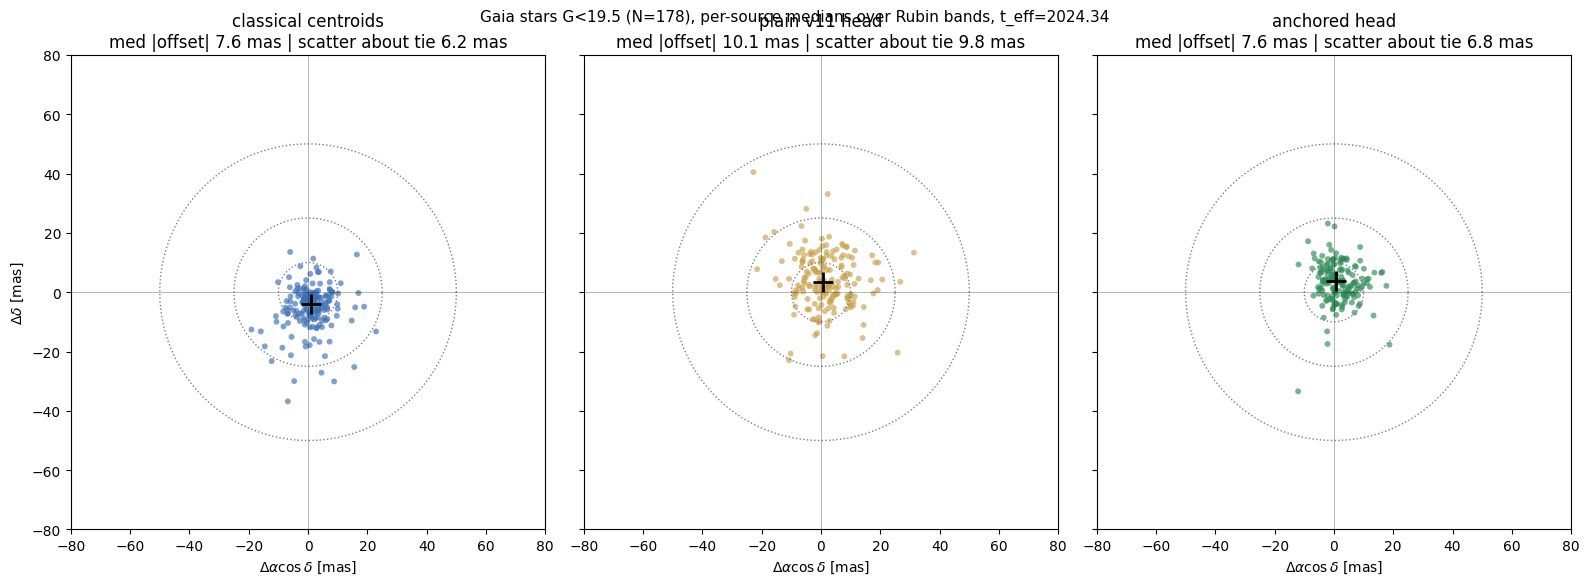

classical centroids    med|off|   7.6  scatter-about-tie   6.2 mas  tie (+1.1,-4.1)
plain v11 head         med|off|  10.1  scatter-about-tie   9.8 mas  tie (+0.8,+3.6)
anchored head          med|off|   7.6  scatter-about-tie   6.8 mas  tie (+0.9,+3.7)

anchored - classical per-star difference: median |d| 11.4 mas (center (+0.9,+8.8))


In [3]:
# --- bright stars vs Gaia: classical / plain / anchored ---
bx=(gm.ra.values-gra[gm.gi])*cosd*3.6e6; by=(gm.dec.values-gde[gm.gi])*3.6e6
vx=bx-s_r*gm.rx.values; vy=by-s_r*gm.ry.values          # VIS label vs Gaia
gm2=gm.copy()
gm2['clx'],gm2['cly']=bx,by                              # classical band centroid vs Gaia
gm2['plx'],gm2['ply']=vx+s_r*gm.px.values, vy+s_r*gm.py.values
gm2['anx'],gm2['any_']=vx+s_r*gm.ex.values, vy+s_r*gm.ey.values
bright=gm2[gmag[gm2.gi]<19.5]
per=bright.groupby('src')[['clx','cly','plx','ply','anx','any_']].median()
panels=[(per.clx,per.cly,'classical centroids','#3b6fb6'),
        (per.plx,per.ply,'plain v11 head','#c8a24b'),
        (per.anx,per.any_,'anchored head','#2e8b57')]
fig,axes=plt.subplots(1,3,figsize=(16,5.6),sharex=True,sharey=True)
stats={}
for ax,(x,y,title,col) in zip(axes,panels):
    tie=np.median(x),np.median(y)
    r=np.hypot(x,y); rt=np.hypot(x-tie[0],y-tie[1])
    stats[title]=(np.median(r),np.median(rt),tie)
    ax.scatter(x,y,s=18,alpha=0.65,color=col,edgecolors='none')
    for rad in [10,25,50]:
        th=np.linspace(0,2*np.pi,200); ax.plot(rad*np.cos(th),rad*np.sin(th),ls=':',color='gray',lw=1)
    ax.plot(*tie,marker='+',ms=14,mew=2,color='k')
    ax.axhline(0,color='k',lw=0.5,alpha=0.4); ax.axvline(0,color='k',lw=0.5,alpha=0.4)
    ax.set(xlim=(-80,80),ylim=(-80,80),aspect='equal',xlabel=r'$\Delta\alpha\cos\delta$ [mas]',
           title=f'{title}\nmed |offset| {np.median(r):.1f} mas | scatter about tie {np.median(rt):.1f} mas')
axes[0].set_ylabel(r'$\Delta\delta$ [mas]')
fig.suptitle(f'Gaia stars G<19.5 (N={len(per)}), per-source medians over Rubin bands, t_eff={TEFF:.2f}',fontsize=11)
plt.tight_layout(); fig.savefig(OUT/'nb32_gaia_three_estimators.png',dpi=140,bbox_inches='tight'); plt.show()
for k,(mr,mrt,tie) in stats.items():
    print(f'{k:22s} med|off| {mr:5.1f}  scatter-about-tie {mrt:5.1f} mas  tie ({tie[0]:+.1f},{tie[1]:+.1f})')

# head-vs-classical convention agreement on these stars (teacher-bias probe)
dxa=per.anx-per.clx; dya=per.any_-per.cly
print(f'\nanchored - classical per-star difference: median |d| {np.median(np.hypot(dxa,dya)):.1f} mas '
      f'(center ({np.median(dxa):+.1f},{np.median(dya):+.1f}))')

### Reading: the external ruler clears the anchored head

- **Epoch caveat closed.** The Q1 coadds' effective epoch is **t_eff = 2024.34** (the DR1-era
  2024.83 was a property of those older coadds). All three estimators give the same epoch
  (2024.34 / 2024.34 / 2024.40) — it is a property of the data, not the head. Fig 9's Gaia
  annotation must switch to the Q1 value.
- **Anchored = classical on the external ruler.** Median offset vs Gaia 7.6 mas for both;
  scatter about the frame tie 6.8 vs 6.2 mas. The plain head pays a real Gaia penalty
  (10.1 / 9.8 mas — its convention bias is visible to an external ruler); the anchored head
  does not. Amortization now costs nothing on bright stars.
- **The 8–9 mas Dec split between the classical and head ties is the concordance field, not a
  pathology.** Classical Rubin band centroids live in the Rubin frame (tie Dec −4.1); the heads
  are trained to the VIS convention (tie Dec +3.7); the separation (~7.8 mas) matches the
  measured common field component (6.9 mas), with Gaia sitting between the two frames. The
  anchored−classical per-star difference (median 11.4 mas, centered at +8.8 Dec) is the same
  statement seen per source.
- **Router (Fig 8.5) implication:** with anchored at classical parity on stars and far ahead
  everywhere else, a sigma-router blend has at most ~0.5 mas to collect on bright stars alone —
  the section is obsolete.

anchored   calibration factor 0.79 (1=perfect) | coverage@50% 63.4% @90% 91.0%
plain v11  calibration factor 1.11 (1=perfect) | coverage@50% 45.2% @90% 73.6%


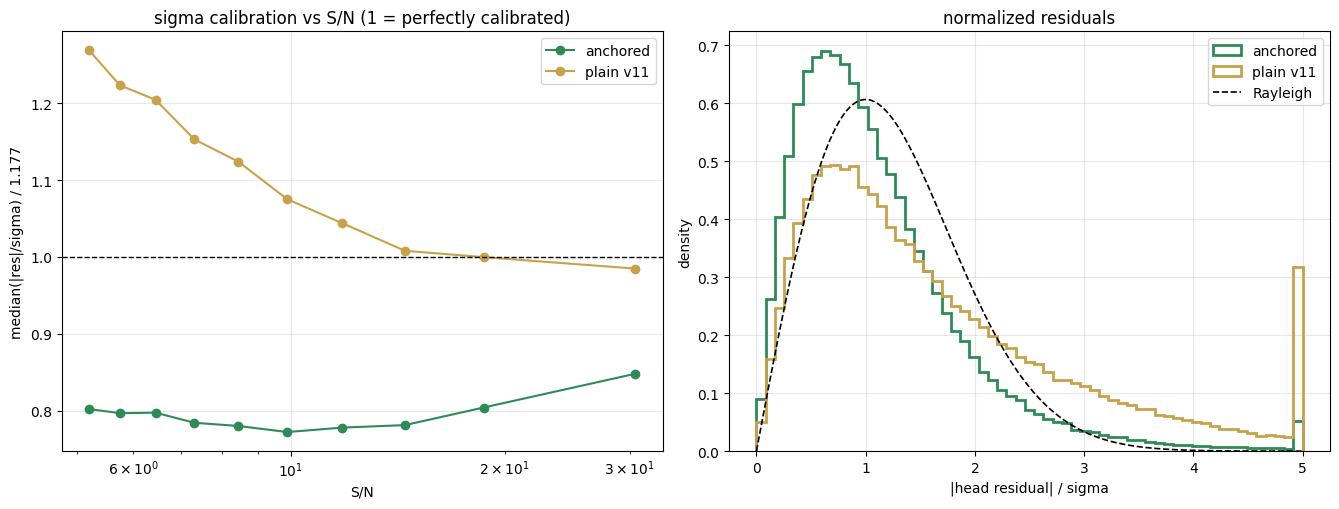

In [4]:
# --- sigma calibration: |head residual| / sigma vs Rayleigh (median = 1.177) ---
RAY=1.17741
fig,axs=plt.subplots(1,2,figsize=(13.5,5.2))
for tag,ex,ey,sg,col in [('anchored',long.ex,long.ey,long.sig,'#2e8b57'),
                         ('plain v11',long.px,long.py,long.sigP,'#c8a24b')]:
    z=np.hypot(ex,ey)/sg
    cal=np.median(z)/RAY
    cov50=(z<RAY).mean(); cov90=(z<2.146).mean()
    print(f'{tag:10s} calibration factor {cal:.2f} (1=perfect) | coverage@50% {cov50:.1%} @90% {cov90:.1%}')
    qs=np.quantile(long.snr,np.linspace(0,1,11)); qs[0]-=1
    mid=[]; cals=[]
    for a,b in zip(qs[:-1],qs[1:]):
        m=(long.snr>a)&(long.snr<=b)
        mid.append(np.median(long.snr[m])); cals.append(np.median(z[m])/RAY)
    axs[0].plot(mid,cals,'o-',color=col,label=tag)
    axs[1].hist(np.clip(z,0,5),bins=np.linspace(0,5,60),histtype='step',lw=2,density=True,color=col,label=tag)
axs[0].axhline(1,color='k',ls='--',lw=1); axs[0].set(xscale='log',xlabel='S/N',
    ylabel='median(|res|/sigma) / 1.177',title='sigma calibration vs S/N (1 = perfectly calibrated)')
axs[0].legend(); axs[0].grid(alpha=0.3)
zz=np.linspace(0,5,200); axs[1].plot(zz,zz*np.exp(-zz**2/2),'k--',lw=1.2,label='Rayleigh')
axs[1].set(xlabel='|head residual| / sigma',ylabel='density',title='normalized residuals')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); fig.savefig(OUT/'nb32_sigma_calibration.png',dpi=140,bbox_inches='tight'); plt.show()

### Reading: sigma is usable now, trivially recalibratable

- **Anchored sigma is uniformly conservative:** calibration factor 0.79, *flat in S/N* — a single
  global rescale (×0.79) makes it calibrated everywhere. Coverage 63% at the 50% point (over-
  covered, as expected for conservative sigma) and 91.0% at the 90% point — the tail is honest.
- **Plain sigma was miscalibrated in shape:** factor drifts 1.27 → 0.98 across S/N and the
  normalized-residual histogram has a heavy tail (90% coverage only 73.6%, with a pile-up at
  |res|/sigma > 5) — that tail is the bias population sigma could not flag.
- Verdict: adopt anchored sigma with a global 0.79 recalibration for paper error bars; no
  per-regime correction needed.